# Lecture 03 — Neural Network Foundations

**Machine Learning Applications in Physics (PHYG004 / PHY5006)** · Sogang University, 2026 Spring
Prof. Young Woo Choi

**Data for this notebook: _analytic_** — the quantum harmonic oscillator (QHO) wavefunctions $\psi_n(x)$ have exact closed-form solutions, so every fit can be checked against ground truth.

---

## Overview

This is the **single foundational session** where we build a multi-layer perceptron (MLP) **from scratch**, derive and verify **backpropagation**, survey **activation functions**, and state the **weight-initialization** principle — *once* for the whole course. Everything later (CNNs, GNNs, equivariant nets, generative models) reuses these building blocks; we will not re-derive them.

> **Note (consolidation).** This notebook merges the theory of the former "NN basics" and "MLP" lectures. The *practice* of overfitting, regularization, deep ensembles, and MC-dropout — i.e. **how networks fail to generalize and what we do about it** — is deliberately held back to **Lecture 05 (MLP Deep Dive)**, where it gets the single canonical treatment it deserves.

## Learning objectives

1. Fit **Hooke's law** $F=-kx$ with linear regression and `jax.grad` (warm-up: a neuron with no activation).
2. See **why** stacking linear layers collapses, and how a nonlinear activation rescues expressiveness.
3. Build an **MLP from scratch** in JAX and train it to approximate QHO wavefunctions $\psi_n(x)$.
4. Compare **activation functions** (linear / sigmoid / ReLU / tanh) on oscillatory targets.
5. State the **weight-initialization** principle (Xavier vs. He) — theory once; the hands-on init experiment lives in L05.
6. **Verify** `jax.grad` against finite differences (backpropagation is exact).
7. Re-express the same network with **Flax NNX + Optax**.


In [ ]:
# Install dependencies (run once on Google Colab)
!pip install -q jax jaxlib optax flax matplotlib

In [ ]:
import math

import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import numpy as np
import matplotlib.pyplot as plt

print(f"JAX version:  {jax.__version__}")
print(f"Backend:      {jax.default_backend()}")

# Default course seed (CLAUDE.md convention)
key = jax.random.PRNGKey(42)

---
## Section 1 · Linear Regression — Hooke's Law

The simplest model: **linear regression** by manual gradient descent.

**Hooke's law**: $\;F = -kx$.

Given noisy measurements $(x_i, F_i)$, we recover the spring constant $k$ by minimizing

$$\mathcal{L}(w, b) = \frac{1}{N}\sum_i \big(w x_i + b - F_i\big)^2 .$$

This is a **single neuron with no activation function**. The loss $\mathcal{L}$ plays the role of an *energy*; gradient descent is *energy minimization* (a recurring physicist's-perspective theme).

In [ ]:
# Generate noisy Hooke's law data  (data: synthetic, with known k_true)
k_true = 3.5
N_data = 50

key, k1, k2 = jax.random.split(key, 3)
x_data = jax.random.uniform(k1, (N_data,), minval=-2.0, maxval=2.0)
F_data = -k_true * x_data + 0.3 * jax.random.normal(k2, (N_data,))
print(f"x_data shape: {x_data.shape},  F_data shape: {F_data.shape}")


# Linear model: F_pred = w * x + b
def linear_loss(params, x, y):
    w, b = params
    return jnp.mean((w * x + b - y) ** 2)


# Manual SGD (no optimizer library yet — just gradient descent by hand)
grad_fn = jax.grad(linear_loss)
params = (0.0, 0.0)
lr = 0.1
losses = []
for step in range(200):
    grads = grad_fn(params, x_data, F_data)
    params = (params[0] - lr * grads[0], params[1] - lr * grads[1])
    losses.append(float(linear_loss(params, x_data, F_data)))

w_learned, b_learned = params
print(f"Learned: w = {w_learned:.4f}, b = {b_learned:.4f}")
print(f"True:    w = {-k_true:.4f}, b = 0.0000")
print(f"Recovered spring constant: k = {-w_learned:.4f}  (true: {k_true})")

# Plot fit + loss curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.scatter(x_data, F_data, alpha=0.5, s=20, label="Noisy data")
x_fit = jnp.linspace(-2, 2, 100)
ax1.plot(x_fit, w_learned * x_fit + b_learned, "r-", lw=2,
         label=f"Fit: F = {w_learned:.2f}x + {b_learned:.2f}")
ax1.plot(x_fit, -k_true * x_fit, "k--", lw=1, label=f"True: F = -{k_true}x")
ax1.set_xlabel("Displacement x"); ax1.set_ylabel("Force F")
ax1.set_title("Hooke's Law: Linear Regression")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

ax2.plot(losses, "b-", lw=1.5)
ax2.set_xlabel("Step"); ax2.set_ylabel("MSE Loss")
ax2.set_title("Training Loss"); ax2.set_yscale("log")
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Section 2 · From Linear Models to MLPs

### Why a single linear layer is not enough

A linear model computes $\mathbf{o} = \mathbf{W}\mathbf{x} + \mathbf{b}$. Stacking two linear layers gives

$$\mathbf{o} = \mathbf{W}_2(\mathbf{W}_1\mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2
            = \underbrace{(\mathbf{W}_2\mathbf{W}_1)}_{\mathbf{W}'}\mathbf{x}
            + \underbrace{(\mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2)}_{\mathbf{b}'} .$$

**An affine function of an affine function is still affine.** No depth of *linear* layers escapes linearity.

The fix is a **nonlinear activation** $\sigma(\cdot)$ between layers:

$$\mathbf{h} = \sigma(\mathbf{W}_1\mathbf{x} + \mathbf{b}_1), \qquad \mathbf{o} = \mathbf{W}_2\mathbf{h} + \mathbf{b}_2 .$$

With a nonlinearity, an MLP can approximate *any* continuous function (Universal Approximation Theorem — [Cybenko 1989](https://doi.org/10.1007/BF02551274); [Hornik et al. 1989](https://doi.org/10.1016/0893-6080(89)90020-8)).

In [ ]:
# Numerical proof: two stacked linear layers collapse to one
key_demo = jax.random.PRNGKey(0)
ka, kb = jax.random.split(key_demo)
W1 = jax.random.normal(ka, (4, 3))
W2 = jax.random.normal(kb, (2, 4))
x_vec = jnp.array([1.0, 2.0, 3.0])

out_two = W2 @ (W1 @ x_vec)        # apply layer 1, then layer 2
out_one = (W2 @ W1) @ x_vec        # collapsed single matrix
print("Two linear layers:", out_two)
print("Collapsed W2·W1 :", out_one)
print("Max difference   :", float(jnp.max(jnp.abs(out_two - out_one))))
print("=> identical: stacking *linear* layers adds no expressiveness.")

**MLP architecture (pre-rendered).** Left: a bare linear model. Right: one hidden layer with an activation $\sigma$ between the affine maps.

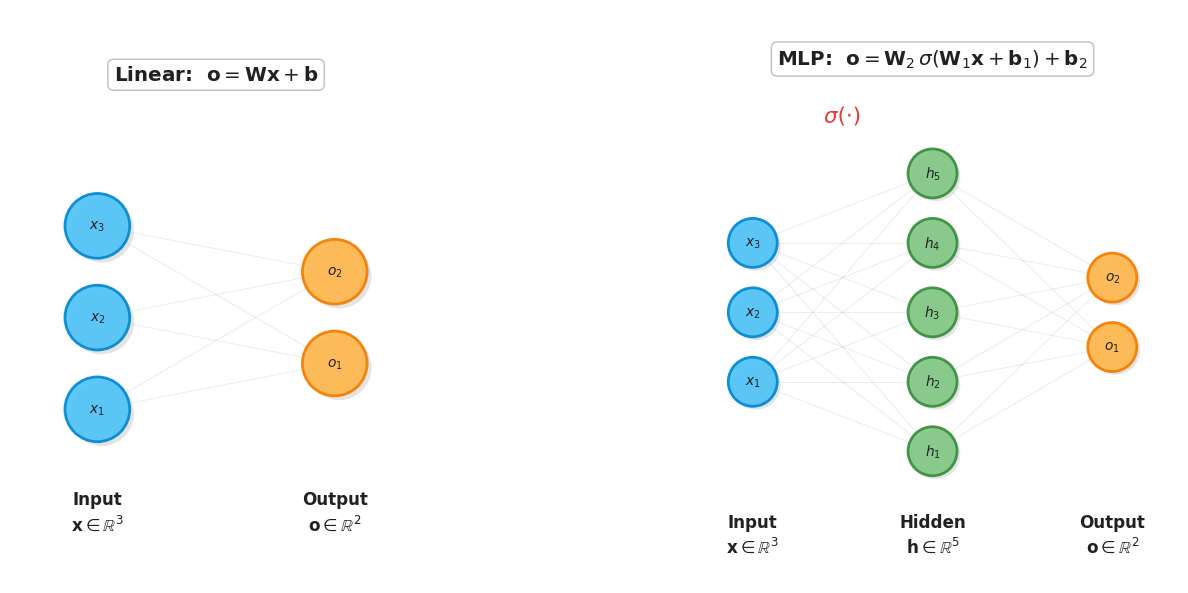

The hidden units $h_j$ are the network's *learned features*. A physicist may read them as **adaptive basis functions** — like choosing a good set of trial orbitals, except the basis is optimized by gradient descent rather than fixed in advance.

---
## Section 3 · Activation Functions and the MLP Builder

Before coding the network, let us look at the three standard activations and — crucially — their **derivatives**, since backpropagation multiplies these together across layers.

| Function | Formula | Range | Derivative |
|----------|---------|-------|------------|
| **ReLU** | $\max(0, x)$ | $[0, \infty)$ | $1$ if $x>0$, else $0$ |
| **Sigmoid** | $1/(1+e^{-x})$ | $(0, 1)$ | $\sigma(x)\,(1-\sigma(x))$ |
| **Tanh** | $(e^x-e^{-x})/(e^x+e^{-x})$ | $(-1, 1)$ | $1 - \tanh^2(x)$ |

> **Physics analogy.** Activations are *response functions*. ReLU is a rectifier diode (passes positive, blocks negative); sigmoid is the Fermi–Dirac occupation; tanh is magnetization vs. applied field.

In [ ]:
# Plot the three activations and their (auto-differentiated) derivatives
def relu(x):    return jnp.maximum(0.0, x)
def sigmoid(x): return 1.0 / (1.0 + jnp.exp(-x))
def tanh(x):    return jnp.tanh(x)

# jax.grad gives us the derivatives for free — vmap to apply elementwise
relu_grad    = jax.vmap(jax.grad(relu))
sigmoid_grad = jax.vmap(jax.grad(sigmoid))
tanh_grad    = jax.vmap(jax.grad(tanh))

xs = jnp.linspace(-5, 5, 500)
acts = [
    (relu, relu_grad, "ReLU", r"$\max(0,x)$", "#e74c3c"),
    (sigmoid, sigmoid_grad, "Sigmoid", r"$1/(1+e^{-x})$", "#2ecc71"),
    (tanh, tanh_grad, "Tanh", r"$\tanh(x)$", "#3498db"),
]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i, (fn, gfn, name, formula, color) in enumerate(acts):
    axes[0, i].plot(xs, fn(xs), color=color, lw=2.5)
    axes[0, i].set_title(f"{name}: {formula}", fontsize=12, fontweight="bold")
    axes[1, i].plot(xs, gfn(xs), color=color, lw=2.5)
    axes[1, i].set_title(f"derivative of {name}", fontsize=12, fontweight="bold")
    for r in (0, 1):
        axes[r, i].axhline(0, color="gray", lw=0.5, ls="--")
        axes[r, i].axvline(0, color="gray", lw=0.5, ls="--")
        axes[r, i].grid(True, alpha=0.3); axes[r, i].set_xlabel("x")
plt.tight_layout(); plt.show()

print("Key point for backprop:")
print("  ReLU derivative is 0 or 1   -> gradient never shrinks (for x>0)")
print("  sigmoid/tanh derivatives < 1 -> products decay over depth (vanishing gradient)")

### Building the MLP from scratch

An MLP with $L$ layers computes

$$\mathbf{h}^{(l)} = \sigma\!\big(\mathbf{h}^{(l-1)}\mathbf{W}^{(l)} + \mathbf{b}^{(l)}\big),\quad l=1,\dots,L-1,
\qquad \hat{\mathbf{y}} = \mathbf{h}^{(L-1)}\mathbf{W}^{(L)} + \mathbf{b}^{(L)} .$$

**Initialization.** We use **He initialization** $W_{ij}\sim\mathcal{N}(0,\,2/n_\text{in})$, which is the right choice for ReLU networks (see Section 4 for the derivation). We keep one consistent `init_mlp` for the whole course.

> **Init consistency note.** The older "NN basics" and "MLP" notebooks disagreed — one used He ($\sqrt{2/n_\text{in}}$), the other Xavier ($\sqrt{2/(n_\text{in}+n_\text{out})}$). We resolve that here: **`init_mlp` uses He** for hidden layers. For these shallow ($\le 4$-layer) demos Xavier would also work fine; He is the safe default once you go deeper or rely on ReLU.

In [ ]:
def init_mlp(key, layer_sizes):
    """Initialize MLP parameters with He init: W ~ N(0, 2/n_in).

    NOTE: <=4 layers, Xavier sqrt(2/(n_in+n_out)) would also be fine; we use
    He = sqrt(2/n_in) as the safe default for ReLU / deeper networks.
    """
    params = []
    for i in range(len(layer_sizes) - 1):
        key, sk = jax.random.split(key)
        n_in, n_out = layer_sizes[i], layer_sizes[i + 1]
        W = jax.random.normal(sk, (n_in, n_out)) * jnp.sqrt(2.0 / n_in)  # He
        b = jnp.zeros(n_out)
        params.append((W, b))
    return params


def mlp_forward(params, x, activation=jax.nn.relu):
    """Forward pass: activation on hidden layers, linear output."""
    for W, b in params[:-1]:
        x = activation(x @ W + b)
    W, b = params[-1]
    return x @ W + b  # no activation on the output


# Inspect a [1, 64, 64, 1] network
key, sk = jax.random.split(key)
test_params = init_mlp(sk, [1, 64, 64, 1])
total = 0
for i, (W, b) in enumerate(test_params):
    n = W.size + b.size
    total += n
    print(f"Layer {i+1}: W {W.shape}, b {b.shape} -> {n} params")
print(f"Total parameters: {total}")

x_test = jnp.linspace(-3, 3, 100).reshape(-1, 1)
y_test = mlp_forward(test_params, x_test)
print(f"\nInput shape:  {x_test.shape}")
print(f"Output shape: {y_test.shape}")

---
## Section 4 · Quantum Harmonic Oscillator Wavefunctions

Our first physics target. With $m=\omega=\hbar=1$ the QHO has exact solutions

$$\psi_n(x) = \frac{1}{\sqrt{2^n n!\sqrt{\pi}}}\, e^{-x^2/2}\, H_n(x),$$

where $H_n$ are (physicist's) Hermite polynomials. This is an ideal first ML-for-physics problem:

- **Analytic** ground truth for verification (data label: *analytic*).
- $n=0$ is a Gaussian — easy for any network.
- Excited states have **nodes** — they demand expressive networks.
- It is the **variational method** in disguise: trial function $\to$ loss $\to$ minimize.

In [ ]:
def hermite(n, x):
    """Physicist's Hermite polynomial H_n(x) via recurrence."""
    if n == 0:
        return jnp.ones_like(x)
    if n == 1:
        return 2 * x
    H_prev, H_curr = jnp.ones_like(x), 2 * x
    for k in range(2, n + 1):
        H_prev, H_curr = H_curr, 2 * x * H_curr - 2 * (k - 1) * H_prev
    return H_curr


def psi_n(x, n):
    """QHO wavefunction psi_n(x) with m = omega = hbar = 1."""
    norm = 1.0 / jnp.sqrt(2**n * math.factorial(n) * jnp.sqrt(jnp.pi))
    return norm * jnp.exp(-x**2 / 2) * hermite(n, x)


x_plot = jnp.linspace(-5, 5, 500)
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for n, ax in enumerate(axes):
    psi = psi_n(x_plot, n)
    ax.plot(x_plot, psi, "b-", lw=2)
    ax.axhline(0, color="k", lw=0.5)
    ax.fill_between(x_plot, psi, alpha=0.15, color="blue")
    ax.set_title(f"$\\psi_{n}(x)$", fontsize=14)
    ax.set_xlabel("x"); ax.set_xlim(-5, 5); ax.grid(True, alpha=0.3)
axes[0].set_ylabel("$\\psi(x)$")
plt.suptitle("Quantum Harmonic Oscillator Wavefunctions", fontsize=13, y=1.03)
plt.tight_layout(); plt.show()

print("n=0: Gaussian, no nodes  -> easy")
print("n=1: 1 node (sign change)")
print("n=2: 2 nodes")
print("n=3: 3 nodes -> hardest for small networks")

### Training infrastructure

We use `optax.adam` for reliable convergence (Adam adapts the per-parameter step — details in Lecture 05). The loop is still explicit: **forward → loss → backward → update**.

In [ ]:
def make_trainer(lr=1e-3, activation=jax.nn.relu):
    """Create a JIT-compiled Adam training step for an MLP."""
    tx = optax.adam(lr)

    def loss_fn(params, x, y):
        return jnp.mean((mlp_forward(params, x, activation=activation) - y) ** 2)

    @jax.jit
    def train_step(params, opt_state, x, y):
        loss, grads = jax.value_and_grad(loss_fn)(params, x, y)
        updates, opt_state = tx.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, opt_state, loss

    return tx, train_step, loss_fn


# Train on psi_0 (ground state)
key, k1, k2 = jax.random.split(key, 3)
x_train = jax.random.uniform(k1, (200, 1), minval=-5.0, maxval=5.0)
y_train = psi_n(x_train[:, 0], 0).reshape(-1, 1)
print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")

params = init_mlp(k2, [1, 64, 64, 1])
tx, train_step, loss_fn = make_trainer(lr=1e-3)
opt_state = tx.init(params)

losses = []
for epoch in range(3000):
    params, opt_state, loss = train_step(params, opt_state, x_train, y_train)
    losses.append(float(loss))

x_eval = jnp.linspace(-5, 5, 500).reshape(-1, 1)
y_pred = mlp_forward(params, x_eval)
y_exact = psi_n(x_eval[:, 0], 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(x_eval, y_exact, "b-", lw=2, label="Exact $\\psi_0(x)$")
ax1.plot(x_eval, y_pred, "r--", lw=2, label="MLP prediction")
ax1.scatter(x_train[:20], y_train[:20], s=15, alpha=0.3, color="gray", label="Train (subset)")
ax1.set_xlabel("x"); ax1.set_ylabel("$\\psi_0(x)$")
ax1.set_title("Ground State: MLP vs Exact"); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(losses, "b-", lw=0.8)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("MSE Loss")
ax2.set_title("Training Loss"); ax2.set_yscale("log"); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Final MSE loss: {losses[-1]:.2e}")

> ### ✅ Checkpoint 1 — your first physics fit
>
> Train an MLP with `layer_sizes = [1, 32, 32, 1]` to fit the ground state $\psi_0$ (a Gaussian). Drive the training loss **below $5\times10^{-4}$** before moving on, then verify the prediction matches the exact wavefunction. Fill in the `TODO`s.

In [ ]:
# CHECKPOINT 1: fit psi_0 with a [1, 32, 32, 1] network to loss < 5e-4
key, k1, k2 = jax.random.split(key, 3)
x_cp = jax.random.uniform(k1, (200, 1), minval=-5.0, maxval=5.0)
y_cp = psi_n(x_cp[:, 0], 0).reshape(-1, 1)

# TODO 1: initialize a [1, 32, 32, 1] MLP
params_cp = init_mlp(k2, [1, 32, 32, 1])          # <-- TODO: set layer_sizes

# TODO 2: build the trainer and run enough epochs to reach loss < 5e-4
tx_cp, step_cp, lossfn_cp = make_trainer(lr=1e-3)
opt_cp = tx_cp.init(params_cp)
for epoch in range(4000):                          # <-- TODO: enough epochs?
    params_cp, opt_cp, loss_cp = step_cp(params_cp, opt_cp, x_cp, y_cp)

print(f"Final training loss: {float(loss_cp):.2e}")
assert float(loss_cp) < 5e-4, "Keep training: loss must be < 5e-4"

# Verify the fit matches the analytic ground state on a dense grid
x_chk = jnp.linspace(-5, 5, 500).reshape(-1, 1)
pred = mlp_forward(params_cp, x_chk)[:, 0]
exact = psi_n(x_chk[:, 0], 0)
ok = bool(jnp.allclose(pred, exact, atol=0.05))
print(f"jnp.allclose(pred, psi_0, atol=0.05): {ok}")
assert ok, "Prediction not yet within 0.05 of the exact psi_0 everywhere."
print("Checkpoint 1 passed.")

### Fitting excited states

Higher states have more **nodes**; wider networks help.

In [ ]:
network_configs = {0: [1, 64, 64, 1], 1: [1, 64, 64, 1],
                   2: [1, 128, 128, 1], 3: [1, 128, 128, 1]}
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
x_eval = jnp.linspace(-5, 5, 500).reshape(-1, 1)
for n_state, ax in enumerate(axes.flatten()):
    key, k1, k2 = jax.random.split(key, 3)
    x_tr = jax.random.uniform(k1, (300, 1), minval=-5.0, maxval=5.0)
    y_tr = psi_n(x_tr[:, 0], n_state).reshape(-1, 1)
    sizes = network_configs[n_state]
    p = init_mlp(k2, sizes)
    tx_n, step_n, _ = make_trainer(lr=1e-3)
    opt_n = tx_n.init(p)
    for epoch in range(5000):
        p, opt_n, loss = step_n(p, opt_n, x_tr, y_tr)
    y_pred_n = mlp_forward(p, x_eval)
    y_exact_n = psi_n(x_eval[:, 0], n_state)
    ax.plot(x_eval, y_exact_n, "b-", lw=2, label="Exact")
    ax.plot(x_eval, y_pred_n, "r--", lw=2, label="MLP")
    ax.set_title(f"$\\psi_{n_state}(x)$ — {sizes}, loss={float(loss):.1e}")
    ax.set_xlabel("x"); ax.axhline(0, color="k", lw=0.5)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_xlim(-5, 5)
plt.suptitle("MLP Approximations of QHO Wavefunctions", fontsize=13)
plt.tight_layout(); plt.show()
print("psi_0 Gaussian (easy); psi_1 one node; psi_2/psi_3 several nodes (wider nets).")

---
## Section 5 · Activation Function Comparison on $\psi_2$

We now fix the target to $\psi_2(x)$ (two nodes) and swap the activation:

- **No activation (linear)** — collapses to a line.
- **Sigmoid** — smooth but saturates → slow gradients.
- **ReLU** — piecewise linear, good general-purpose.
- **Tanh** — zero-centered and smooth → often best on *smooth* targets.

In [ ]:
target_n = 2
key, sk = jax.random.split(key)
x_act = jax.random.uniform(sk, (300, 1), minval=-5.0, maxval=5.0)
y_act = psi_n(x_act[:, 0], target_n).reshape(-1, 1)

activations = [
    ("No activation (linear)", lambda x: x),
    ("Sigmoid", jax.nn.sigmoid),
    ("ReLU", jax.nn.relu),
    ("Tanh", jnp.tanh),
]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
x_eval = jnp.linspace(-5, 5, 500).reshape(-1, 1)
y_exact_act = psi_n(x_eval[:, 0], target_n)
final = {}
for (name, act_fn), ax in zip(activations, axes.flatten()):
    key, sk = jax.random.split(key)
    p = init_mlp(sk, [1, 128, 128, 1])
    tx_a, step_a, _ = make_trainer(lr=1e-3, activation=act_fn)
    opt_a = tx_a.init(p)
    for epoch in range(3000):
        p, opt_a, loss = step_a(p, opt_a, x_act, y_act)
    final[name] = float(loss)
    y_pred_a = mlp_forward(p, x_eval, activation=act_fn)
    ax.plot(x_eval, y_exact_act, "b-", lw=2, label="Exact $\\psi_2$")
    ax.plot(x_eval, y_pred_a, "r--", lw=2, label="MLP")
    ax.set_title(f"{name} (loss={float(loss):.1e})")
    ax.set_xlabel("x"); ax.axhline(0, color="k", lw=0.5)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_xlim(-5, 5)
plt.suptitle("Activation Comparison on $\\psi_2(x)$", fontsize=13)
plt.tight_layout(); plt.show()
for k_, v_ in final.items():
    print(f"{k_:28s} final loss = {v_:.2e}")

> ### ✅ Checkpoint 2 — interpret the comparison
>
> In the experiment above, **tanh** typically reaches a *lower* final loss than ReLU when reproducing $\psi_2$ (a smooth function with two nodes).
>
> **TODO (1–2 sentences):** Why does a smooth, zero-centered activation like tanh tend to fit a smooth target such as $\psi_2$ better than piecewise-linear ReLU? Edit this markdown cell and write your answer below.
>
> *Your answer:* `____`
>
> *(Hint: think about what kind of function each activation builds out of — kinks vs. smooth curves — and how that matches the smoothness of $\psi_2$.)*

---
## Section 6 · Weight Initialization — The Principle (theory, once)

This is the **one place** in the course we derive the initialization rule. The hands-on init experiment (sweeping scales, measuring per-layer activation std on a deep net) lives in **Lecture 05**; here we establish *why*.

### Vanishing and exploding gradients

In an $L$-layer network the gradient w.r.t. early weights involves a **product of many matrices**:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(1)}} \;\propto\; \prod_{l=2}^{L} \mathbf{M}^{(l)} .$$

If the typical singular value of $\mathbf{M}^{(l)}$ is $<1$, the product **vanishes** exponentially; if $>1$, it **explodes**.

> **Physics analogy.** This is a *transfer-matrix* problem: multiply many matrices whose eigenvalues $\ne 1$ and the result decays or blows up — exactly as in tight-binding chains or optical multilayer stacks.

In [ ]:
# Multiply many random matrices: norm grows or shrinks exponentially with depth
key_init = jax.random.PRNGKey(0)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
n = 10
for ax, (scale, title, color) in zip(axes, [
    (0.5, "Vanishing (typical s.v. < 1)", "#3498db"),
    (1.5, "Exploding (typical s.v. > 1)", "#e74c3c"),
]):
    norms = []
    for n_layers in range(1, 51):
        result = jnp.eye(n)
        kk = key_init
        for _ in range(n_layers):
            kk, sk = jax.random.split(kk)
            M = jax.random.normal(sk, (n, n)) * scale / jnp.sqrt(n)
            result = result @ M
        norms.append(float(jnp.linalg.norm(result)))
    ax.semilogy(range(1, 51), norms, "o-", color=color, ms=4, lw=1.5)
    ax.set_xlabel("Number of layers"); ax.set_ylabel(r"$\|\prod M^{(l)}\|$")
    ax.set_title(title, fontweight="bold"); ax.grid(True, alpha=0.3)
plt.suptitle("Matrix products grow/shrink exponentially with depth", fontweight="bold")
plt.tight_layout(); plt.show()

### Xavier vs. He: choose the variance to preserve signal

Pick the initial weight variance so signal magnitude is roughly preserved layer to layer. For a layer with $n_\text{in}$ inputs and $n_\text{out}$ outputs:

- forward pass wants $\,n_\text{in}\,\mathrm{Var}(w) = 1$,
- backward pass wants $\,n_\text{out}\,\mathrm{Var}(w) = 1$.

**Xavier / Glorot** compromise ([Glorot & Bengio 2010](http://proceedings.mlr.press/v9/glorot10a.html)):

$$\mathrm{Var}(w) = \frac{2}{n_\text{in} + n_\text{out}} .$$

**He / Kaiming** for ReLU ([He et al. 2015](https://arxiv.org/abs/1502.01852)): ReLU zeroes half its inputs, halving the variance, so use

$$\mathrm{Var}(w) = \frac{2}{n_\text{in}} .$$

> **Course rule.** Xavier works fine for shallow ($\le 4$-layer) networks; once you use **ReLU in a deeper network, prefer He** $\big(\text{scale}=\sqrt{2/n_\text{in}}\big)$. Our `init_mlp` already uses He — consistent everywhere in this course.
>
> **Symmetry breaking.** Weights must be initialized *randomly*. Identical weights make every neuron compute the same function and receive the same gradient — they stay identical forever (a degenerate, never-broken symmetry).

> ### ✅ Checkpoint 3 — see He keep the signal alive
>
> Take a **deep** ReLU net (`depth = 10`) and plot, layer by layer, the **standard deviation of the activations** under Xavier vs. He initialization. You should see Xavier's activations **decay** with depth (because ReLU eats half the variance), while He **holds std ≈ 1**. Fill in the two `scale` `TODO`s.

In [ ]:
# CHECKPOINT 3: per-layer activation std, Xavier vs He, on a deep ReLU net
def layerwise_act_std(scale_fn, layer_sizes, x, key):
    """Build a ReLU net with the given init scale and record std per layer."""
    h, stds = x, []
    for i in range(len(layer_sizes) - 1):
        key, sk = jax.random.split(key)
        n_in, n_out = layer_sizes[i], layer_sizes[i + 1]
        W = jax.random.normal(sk, (n_in, n_out)) * scale_fn(n_in, n_out)
        h = jax.nn.relu(h @ W)            # bias = 0, hidden layers
        stds.append(float(jnp.std(h)))
    return stds

depth = 10
layer_sizes = [128] * (depth + 1)
x_in = jax.random.normal(jax.random.PRNGKey(99), (256, 128))

# TODO: fill in the two init scales
xavier_scale = lambda n_in, n_out: jnp.sqrt(2.0 / (n_in + n_out))   # <-- TODO Xavier
he_scale     = lambda n_in, n_out: jnp.sqrt(2.0 / n_in)            # <-- TODO He

xavier_std = layerwise_act_std(xavier_scale, layer_sizes, x_in, jax.random.PRNGKey(1))
he_std     = layerwise_act_std(he_scale,     layer_sizes, x_in, jax.random.PRNGKey(1))

plt.figure(figsize=(7, 4))
plt.plot(range(1, depth + 1), xavier_std, "o-", label="Xavier", color="#3498db")
plt.plot(range(1, depth + 1), he_std, "s-", label="He", color="#e74c3c")
plt.axhline(1.0, color="gray", ls="--", lw=1, label="std = 1 (ideal)")
plt.xlabel("Layer"); plt.ylabel("std of activations"); plt.yscale("log")
plt.title(f"Activation std through a depth-{depth} ReLU net")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
print("Xavier last-layer std:", f"{xavier_std[-1]:.3f}", " He last-layer std:", f"{he_std[-1]:.3f}")
print("He keeps std ~ 1 with depth; Xavier (under ReLU) decays.")

---
## Section 7 · Backpropagation Verification

`jax.grad` performs **reverse-mode automatic differentiation** — exact, machine-precision gradients. We confirm it against a finite-difference estimate:

$$\frac{\partial f}{\partial \theta_i} \approx \frac{f(\theta_i+\epsilon) - f(\theta_i-\epsilon)}{2\epsilon} .$$

In [ ]:
# Gradient check on a tiny network
key, sk = jax.random.split(key)
tiny_params = init_mlp(sk, [1, 4, 1])
x_check = jnp.array([[1.5]]); y_check = jnp.array([[0.7]])


def flat_loss(flat_p, shapes, x, y):
    """Reconstruct params from a flat vector and compute MSE."""
    params, idx = [], 0
    for w_shape, b_shape in shapes:
        w_size = w_shape[0] * w_shape[1]
        W = flat_p[idx:idx + w_size].reshape(w_shape); idx += w_size
        b = flat_p[idx:idx + b_shape[0]]; idx += b_shape[0]
        params.append((W, b))
    return jnp.mean((mlp_forward(params, x) - y) ** 2)


flat_p = jnp.concatenate([jnp.concatenate([W.ravel(), b.ravel()]) for W, b in tiny_params])
shapes = [(W.shape, b.shape) for W, b in tiny_params]

auto_grad = jax.grad(flat_loss)(flat_p, shapes, x_check, y_check)

eps = 1e-5
fd_grad = []
for i in range(len(flat_p)):
    p_plus = flat_p.at[i].add(eps)
    p_minus = flat_p.at[i].add(-eps)
    g = (flat_loss(p_plus, shapes, x_check, y_check)
         - flat_loss(p_minus, shapes, x_check, y_check)) / (2 * eps)
    fd_grad.append(float(g))
fd_grad = jnp.array(fd_grad)

print("Parameter | jax.grad   | Finite Diff | Abs Error")
print("-" * 55)
for i in range(len(flat_p)):
    ag, fd = float(auto_grad[i]), float(fd_grad[i])
    print(f"  theta[{i:2d}] | {ag:+10.6f} | {fd:+10.6f} | {abs(ag-fd):.2e}")
max_abs_err = float(jnp.max(jnp.abs(auto_grad - fd_grad)))
print(f"\nMax absolute error: {max_abs_err:.2e}")
print("jax.grad is EXACT; the small gap is the O(eps^2) finite-difference error,")
print("amplified by float32 (~7 significant digits).")

---
## Section 8 · The Same Network in Flax NNX + Optax

`flax.nnx` is a cleaner, object-oriented API over the same JAX math:
- `nnx.Module` — base class for models,
- `nnx.Linear` — a built-in linear layer,
- `nnx.Optimizer` — wraps Optax.

Flax is **syntactic sugar** — understand the pure-JAX version first.

In [ ]:
import flax.nnx as nnx


class QHO_MLP(nnx.Module):
    """MLP for approximating QHO wavefunctions (tanh hidden, linear output)."""

    def __init__(self, hidden_sizes, *, rngs):
        sizes = [1] + hidden_sizes + [1]
        self.layers = nnx.List([
            nnx.Linear(s_in, s_out, rngs=rngs)
            for s_in, s_out in zip(sizes[:-1], sizes[1:])
        ])

    def __call__(self, x):
        for layer in self.layers[:-1]:
            x = nnx.tanh(layer(x))
        return self.layers[-1](x)


model = QHO_MLP([64, 64], rngs=nnx.Rngs(42))
optimizer = nnx.Optimizer(model, optax.adam(1e-3), wrt=nnx.Param)


def flax_loss_fn(model, x, y):
    return jnp.mean((model(x) - y) ** 2)


@nnx.jit
def flax_train_step(model, optimizer, x, y):
    loss, grads = nnx.value_and_grad(flax_loss_fn)(model, x, y)
    optimizer.update(model, grads)
    return loss


key, sk = jax.random.split(key)
x_flax = jax.random.uniform(sk, (200, 1), minval=-5.0, maxval=5.0)
y_flax = psi_n(x_flax[:, 0], 0).reshape(-1, 1)

flax_losses = []
for epoch in range(2000):
    flax_losses.append(float(flax_train_step(model, optimizer, x_flax, y_flax)))

x_eval = jnp.linspace(-5, 5, 500).reshape(-1, 1)
y_flax_pred = model(x_eval)
y_flax_exact = psi_n(x_eval[:, 0], 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(x_eval, y_flax_exact, "b-", lw=2, label="Exact $\\psi_0(x)$")
ax1.plot(x_eval, y_flax_pred, "r--", lw=2, label="Flax MLP")
ax1.set_xlabel("x"); ax1.set_ylabel("$\\psi_0(x)$")
ax1.set_title("Flax MLP vs Exact (Ground State)"); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(flax_losses, "b-", lw=0.8)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("MSE Loss")
ax2.set_title("Training Loss (Flax + Adam)"); ax2.set_yscale("log"); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Final loss (Flax + Adam): {flax_losses[-1]:.2e}")

---
## Summary

| What we did | Key takeaway |
|---|---|
| Linear regression (Hooke's law) | Simplest model = single neuron, no activation |
| Linear-collapse demo | Depth without nonlinearity buys nothing |
| MLP from scratch | ~20 lines of JAX = a complete neural network |
| QHO ground/excited states | Gaussian is easy; **nodes** demand wider nets |
| Activation comparison | Linear fails; tanh best on smooth targets; ReLU good default |
| Weight init (theory) | Xavier vs **He**; preserve signal variance across depth |
| Backprop verification | `jax.grad` is exact; finite differences only approximate |
| Flax NNX + Optax | Cleaner API over the same math |

### Connection to physics — the variational method

What we did *is* the variational method: choose a trial wavefunction (the MLP $\psi_\theta$), define a loss (here MSE vs. exact; in real applications the energy functional $\langle\Psi_\theta|\hat{H}|\Psi_\theta\rangle$), and minimize by gradient descent. This is exactly how **neural quantum states** (FermiNet, PsiFormer) work — except they minimize the energy and the exact solution is *unknown*.

---
## 🧵 The course spine — two benchmark systems

Two physical systems recur as **benchmarks all semester**. Recognizing them as a through-line will help you connect lectures:

- **The 2D Ising model** — our discrete, symmetry-breaking workhorse. It returns in **L01** (Monte-Carlo sampling), **L06** (CNN phase classification), and **L07** (real-data / transfer CNNs). Order parameter: magnetization $\langle m\rangle$.

- **The Boltzmann double-well** $\;U(x) = (x^2-1)^2\;$ — our continuous, bimodal sampling target. It returns across the generative block: **L15** (normalizing flows / Boltzmann generators), **L16** (flow matching), and **L17** (diffusion). The challenge is always: *draw samples in proportion to $e^{-U(x)/k_BT}$*.

Today's QHO wavefunctions are the **analytic warm-up**: ground truth is known, so we could check every fit. Most of the systems ahead have *no* closed form — which is exactly why we need the machinery we just built.

---
## Optional Exercise — width vs. number of nodes

Fit a **high** excited state $\psi_5(x)$ (five nodes) and study how the network **width** needed for a good fit grows with the number of nodes.

**TODO.** Sweep `hidden_dim` over `[16, 32, 64, 128]`, train each `[1, hidden_dim, hidden_dim, 1]` net on $\psi_5$, and **tabulate the final loss**. Then answer in 1–2 sentences: from a *degrees-of-freedom* viewpoint, why must the network get wider as the target acquires more nodes?

In [ ]:
# OPTIONAL EXERCISE: fit psi_5 at several widths and tabulate the final loss
target = 5
key, sk = jax.random.split(key)
x_e = jax.random.uniform(sk, (500, 1), minval=-6.0, maxval=6.0)
y_e = psi_n(x_e[:, 0], target).reshape(-1, 1)

print(f"{'hidden_dim':>10} | {'final loss':>12}")
print("-" * 26)
for hidden_dim in [16, 32, 64, 128]:        # <-- TODO: sweep the width
    key, sk = jax.random.split(key)
    p = init_mlp(sk, [1, hidden_dim, hidden_dim, 1])
    tx_e, step_e, _ = make_trainer(lr=1e-3, activation=jnp.tanh)
    opt_e = tx_e.init(p)
    for epoch in range(4000):
        p, opt_e, loss = step_e(p, opt_e, x_e, y_e)
    print(f"{hidden_dim:>10} | {float(loss):>12.2e}")

# TODO (1-2 sentences): why does the required width grow with the number of nodes?
#   Hint: each node is an extra "feature" / degree of freedom the basis must resolve.